In [74]:
import torch
import numpy as np
import torch.nn as nn
from tqdm import trange
from pathlib import Path
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from torchinfo import summary
import time
import sys
import pandas as pd
import sklearn.gaussian_process as gp
import os
from IPython.display import display, Math

import sympy as sp
sys.path.append('../nn_model')
sys.path.append('..')
sys.path.append('../data')

sys.path.append('../GP_regr')

import plot_settings
plot_settings.apply()
COLORS = plot_settings.colors()
import importlib
import SR_lib

import nn_model_lib as _lib

from nn_model_lib import *


def import_reload():
    importlib.reload(plot_settings)
    importlib.reload(SR_lib)


import_reload()

In [75]:
RUN_ID = 'test2'
DT = 1
Q0 = 17921.57581 
SAVE  = False
ITS = int(1e1)

REF_VALUES  = SR_lib.get_ref_values()


VARIABLES = ['R0', 'R1', 'C1','k','sdot','Ue']
REF_VALUES = SR_lib.get_ref_values()

UNITS, UNIT_CONV = SR_lib.get_units_dict()

SELECTION = "best"

In [76]:
model_name = '0515_0840_b4_combo_softplus_combo_V-dynamic_F-dynamic_unconstr_700.40min_16h_2500eps.pt'

BAT_MODEL, ckpt = load_nn_model(model_name)

def R0_nn(c_rate, u_per, soc):
    return element_predict(BAT_MODEL, c_rate, u_per, soc, element='R0')

def R1_nn(c_rate, u_per, soc):
    return element_predict(BAT_MODEL, c_rate, u_per, soc, element='R1')

def C1_nn(c_rate, u_per, soc):
    return element_predict(BAT_MODEL, c_rate, u_per, soc, element='C1')

def k_nn(c_rate, u_per, soc):
    print('Predicting k with NN')
    return element_predict(BAT_MODEL, c_rate, u_per, soc, element='k')

def sdot_nn(c_rate, u_per, soc, s):
    return sdot_predict(BAT_MODEL, c_rate, u_per, soc, s)
# diff_vals = data.max(axis=0) - data.min(axis=0)
# print(diff_vals)

Loaded checkpoint with config: {'R1_mode': 'net', 'C1_mode': 'net', 'R0_mode': 'net', 'n_hidden': 16, 'R1_constrained': 'false', 'R1_min': 0.005, 'R1_max': 0.25, 'C1_constrained': 'false', 'C1_min': 500.0, 'C1_max': 30000.0, 'R0_constrained': 'false', 'R0_min': 0.007, 'R0_max': 0.015, 'k_constrained': 'false', 'k_min': 0.02, 'k_max': 0.04, 's_constrained': 'false', 's_min': 0.0, 's_max': 0.5, 'sdot_constrained': 'false', 'sdot_min': 0.0, 'sdot_max': 0.001, 'style_V': 'dynamic', 'style_F': 'dynamic'}
Using I_ref = 24.89107751102174 and 'u_ref' = 4.297601866251944 for model parameters
k unconstrained
ds/dt unconstrained  (dynamic sdotNet)
R1 unconstrained
C1 unconstrained
R0 unconstrained


In [77]:
print(f"Loading symbolic regression results for RUN_ID: {RUN_ID}")
expressions = SR_lib.extract_expressions(RUN_ID)
print("Extracted expressions for elements:", list(expressions.keys()))


from collections import Counter
VARIABLES = ['R0', 'R1', 'C1', 'k','sdot','Ue']
symbol_counts = {}
for elem in VARIABLES:
    counter = Counter()
    for expr in expressions[elem]:
        sympy_expr = sp.sympify(expr)

        counter.update(map(str, sympy_expr.free_symbols))

    symbol_counts[elem] = counter

# convert to dataframe for better visualization
symbol_counts_df = pd.DataFrame(symbol_counts).fillna(0).astype(int)

for elem in symbol_counts_df:
    symbol_counts_df[elem] = 100 * symbol_counts_df[elem] / expressions[elem].shape[0]

df_symcounts = symbol_counts_df.transpose()
display(df_symcounts)

#df_symcounts.columns = [latent_variables.get(col, col) for col in df_symcounts.columns]
#display(df_symcounts)

# # round values to 1 decimal place
# df_symcounts = df_symcounts.round(1)

# def df_latex_table(df, caption=None, label=None):
#     latex_str = df.to_latex(index=True, escape=False)
#     if caption:
#         latex_str = latex_str.replace('\\begin{tabular}', f'\\begin{{table}}[ht]\n\\centering\n\\caption{{{caption}}}\n\\begin{{tabular}}')
#     if label:
#         latex_str = latex_str.replace('\\end{tabular}', f'\\end{{tabular}}\n\\label{{{label}}}\n\\end{{table}}')
#     return latex_str

# latex_table = df_latex_table(df_symcounts, caption="Symbol usage percentages in SR expressions", label="tab:symbol_usage")
# print(latex_table)

# for sym in expressions['s']:
#     sympy_expr = sp.sympify(sym)
#     rounded_expr = sympy_expr.xreplace({n: sp.Float(round(float(n), 3)) for n in sympy_expr.atoms(sp.Float)})
#     print(f"s = {sp.latex(rounded_expr)}")

Loading symbolic regression results for RUN_ID: test2
Extracted expressions for elements: ['R0', 'R1', 'C1', 'k', 'sdot', 'Ue']


,soc,C,d,s
R0,90.909091,36.363636,36.363636,0.000000
R1,85.714286,71.428571,0.000000,0.000000
C1,92.307692,30.769231,0.000000,0.000000
k,50.000000,0.000000,90.000000,0.000000
sdot,15.384615,92.307692,76.923077,7.692308
Ue,92.307692,0.000000,0.000000,0.000000


In [78]:
def display_expresions(elem, expressions = expressions, complexity = None, loss = None, ref_values = REF_VALUES):
    latex_dict = SR_lib.get_latex_dict()

    print(f"\nExpression for {elem}:")
    for j,expr in enumerate(expressions[elem]):
        sympy_expr = sp.sympify(expr)
        if complexity is not None:
            #display(Math(f"\\Large {complexity[j]}, idx: {j}: {elem} = {sp.latex(ref_values[elem] * sympy_expr)}"))
            display(Math(f"\\Large {j},\\quad comp\\ {complexity[j]},\\quad {latex_dict[elem]} = {sp.latex(sympy_expr.evalf(3))}"))
        else:
            display(Math(f"\\Large {j}: {latex_dict[elem]} = {sp.latex(sympy_expr)}"))

Loading symbolic regression results for RUN_ID: test2


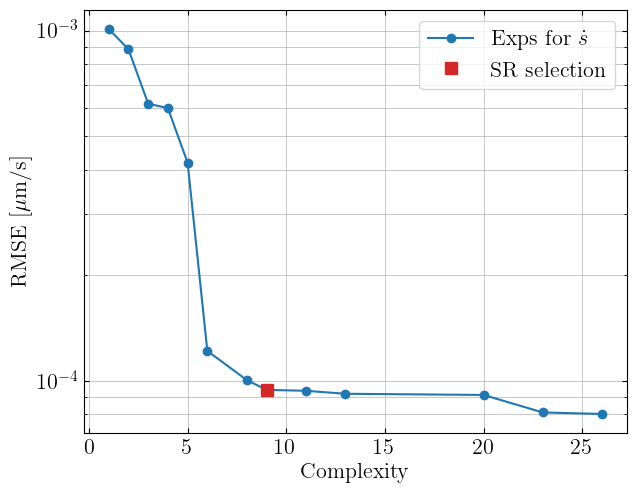


Expression for sdot:


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

...

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [79]:
#RUN_ID = '1305_hSOC'

diff_vals = 1
def post_pareto_plot(elem, run_id, colors = COLORS, diff = diff_vals, ref_values = REF_VALUES, save = SAVE, inds = None):
    #print(f'sr_models/model_{elem}_{run_id}.csv')
    latex_dict = SR_lib.get_latex_dict()
    units_dict, unit_conversion = SR_lib.get_units_dict()
    print(f"Loading symbolic regression results for RUN_ID: {run_id}")
    df_model = pd.read_csv(f'saved_sr_models/{RUN_ID}/model_{elem}_{run_id}.csv')
    best = pd.read_csv(f'saved_sr_models/{RUN_ID}/model_{elem}_best_{run_id}.csv')
    best_complexity = float(best.iloc[0, 0])
    best_rows = df_model[np.isclose(df_model['complexity'], best_complexity)]
    best_ind = int(best.iloc[0,0])

    plt.figure(figsize=(7, 5.5))
    plt.xticks(np.arange(0, df_model['complexity'].max() + 1, 5))
    plt.grid(True, which="both", ls="-", linewidth=0.5)
    plt.plot(df_model['complexity'], np.sqrt(df_model['loss']) * ref_values[elem] * unit_conversion[elem], marker='o', linestyle='-', color=colors[0], label=fr'Exps for ${latex_dict[elem]}$', markersize=6)
    plt.plot(best_rows['complexity'],np.sqrt(best_rows['loss']) * ref_values[elem] * unit_conversion[elem], marker='s', linestyle='', color=colors[1], label='SR selection', markersize=8)
    if inds is not None:
        plt.plot(df_model.iloc[inds]['complexity'], np.sqrt(df_model.iloc[inds]['loss']) * ref_values[elem]* unit_conversion[elem], marker='s', linestyle='', color=colors[3], label='Simpler selection', markersize=8)
    plt.xlabel('Complexity')
    plt.ylabel(f'RMSE [{units_dict[elem]}]')
    plt.yscale('log')
    plt.legend()
    plt.savefig(f'SR_figs/SP/model_{elem}_{run_id}_pareto.pdf', bbox_inches='tight') if save else None
    plt.show()

elem = 'sdot'

df = pd.read_csv(f'saved_sr_models/{RUN_ID}/model_{elem}_{RUN_ID}.csv')

complexity = df['complexity'].values

post_pareto_plot(elem, RUN_ID, save = False)

display_expresions(elem, complexity= complexity)

In [80]:
def gen_table(elem, run_id = RUN_ID, units_dict = UNITS, unit_conversion = UNIT_CONV, ref_values = REF_VALUES):
    df_tab =  pd.read_csv(f'saved_sr_models/{run_id}/model_{elem}_{run_id}.csv')

    # df_R0['latex'] = df_R0['sympy_format'].apply(lambda expr: sp.latex(sp.sympify(expr).evalf(3), full_prec=False))

    df_tab['latex'] = df_tab['sympy_format'].apply(lambda expr: f"${sp.latex(sp.sympify(expr).evalf(3), full_prec=False)}$")

    factor = 100
    if elem == 'k' or elem == 's':
        (np.sqrt(df_tab['loss']) * REF_VALUES[elem]* unit_conversion[elem]).round(3)
    else:
        df_tab['loss'] = np.sqrt(df_tab['loss']) * REF_VALUES[elem] * unit_conversion[elem] 
    table_latex = df_tab[['complexity', 'loss', 'latex']].to_latex(index=False, escape=False, float_format="%.3f")
    print(table_latex)

tab_element = 'sdot'
print(f'Generating table for {tab_element}\n')
gen_table(tab_element)


Generating table for sdot

\begin{tabular}{rrl}
\toprule
complexity & loss & latex \\
\midrule
1 & 0.001 & $0.867$ \\
2 & 0.001 & $e^{C}$ \\
3 & 0.001 & $3.02 C$ \\
4 & 0.001 & $- d + e^{C}$ \\
5 & 0.000 & $\frac{C}{d + 0.171}$ \\
6 & 0.000 & $\frac{C}{d^{3} + 0.208}$ \\
8 & 0.000 & $\frac{C}{\left(d + 0.0493\right)^{3} + 0.203}$ \\
9 & 0.000 & $- 4.86 C \left(d - 0.867\right) + C$ \\
11 & 0.000 & $C \left(5.17 - 4.83 d\right)$ \\
13 & 0.000 & $4.94 C \left(1.05 - \left(d^{2}\right)^{0.5}\right) + 0.0283$ \\
20 & 0.000 & $\left(1.1 \left(C^{2} \left({0.0149}^{d}\right)^{d}\right)^{0.106} + 0.212\right)^{6}$ \\
23 & 0.000 & $\left(C \left(0.392 soc + 3.7\right) + C\right) \left(\left(0.0125 C + 0.0999\right)^{d}\right)^{d}$ \\
26 & 0.000 & $\left(C \left(- 0.392 s^{3} + 0.392 soc + 3.7\right) + C\right) \left(\left(0.0125 C + 0.0999\right)^{d}\right)^{d}$ \\
\bottomrule
\end{tabular}

